In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('final_results.csv')
df

,command,mean,stddev,median,user,system,min,max,parameter_qlcf
0,algeria_population_by_wilaya_2022-5,2.076166,0.112413,2.031487,1.998603,0.030808,2.003279,2.369612,5
1,algeria_population_by_wilaya_2022-6,1.484563,0.037879,1.467884,1.458233,0.017364,1.450035,1.563196,6
2,algeria_population_by_wilaya_2022-7,1.033027,0.014018,1.029549,1.011934,0.017452,1.015329,1.060884,7
3,algeria_population_by_wilaya_2022-8,0.946907,0.012979,0.941465,0.922065,0.022809,0.932941,0.972994,8
4,algeria_population_by_wilaya_2022-9,1.063175,0.028266,1.052519,1.018448,0.037701,1.036397,1.134265,9
...,...,...,...,...,...,...,...,...,...
347,csv_wo_antarctica_ne50_antimeridian_minus169_b...,15.895395,1.694849,15.504814,15.498364,0.353869,13.799706,18.354369,11
348,csv_wo_antarctica_ne50_antimeridian_minus169_b...,23.014923,1.701140,22.331057,22.418480,0.532478,21.837921,27.451079,12
349,csv_wo_antarctica_ne50_antimeridian_minus169_b...,36.416206,2.636269,37.004802,35.509632,0.806697,32.901109,39.429698,13
350,csv_wo_antarctica_ne50_antimeridian_minus169_b...,38.008737,0.194551,38.035263,37.044544,0.864251,37.699406,38.296550,14


In [3]:
df[['command', 'neg_expo']] = df['command'].str.rsplit('-', n=1, expand=True)
df['neg_expo'] = df['neg_expo'].astype(int)
df

,command,mean,stddev,median,user,system,min,max,parameter_qlcf,neg_expo
0,algeria_population_by_wilaya_2022,2.076166,0.112413,2.031487,1.998603,0.030808,2.003279,2.369612,5,5
1,algeria_population_by_wilaya_2022,1.484563,0.037879,1.467884,1.458233,0.017364,1.450035,1.563196,6,6
2,algeria_population_by_wilaya_2022,1.033027,0.014018,1.029549,1.011934,0.017452,1.015329,1.060884,7,7
3,algeria_population_by_wilaya_2022,0.946907,0.012979,0.941465,0.922065,0.022809,0.932941,0.972994,8,8
4,algeria_population_by_wilaya_2022,1.063175,0.028266,1.052519,1.018448,0.037701,1.036397,1.134265,9,9
...,...,...,...,...,...,...,...,...,...,...
347,csv_wo_antarctica_ne50_antimeridian_minus169_b...,15.895395,1.694849,15.504814,15.498364,0.353869,13.799706,18.354369,11,11
348,csv_wo_antarctica_ne50_antimeridian_minus169_b...,23.014923,1.701140,22.331057,22.418480,0.532478,21.837921,27.451079,12,12
349,csv_wo_antarctica_ne50_antimeridian_minus169_b...,36.416206,2.636269,37.004802,35.509632,0.806697,32.901109,39.429698,13,13
350,csv_wo_antarctica_ne50_antimeridian_minus169_b...,38.008737,0.194551,38.035263,37.044544,0.864251,37.699406,38.296550,14,14


In [4]:
sum(df["parameter_qlcf"] == df["neg_expo"])

352

In [5]:
df = df[['command', 'mean', 'neg_expo']]
df.head()

,command,mean,neg_expo
0,algeria_population_by_wilaya_2022,2.076166,5
1,algeria_population_by_wilaya_2022,1.484563,6
2,algeria_population_by_wilaya_2022,1.033027,7
3,algeria_population_by_wilaya_2022,0.946907,8
4,algeria_population_by_wilaya_2022,1.063175,9


In [6]:
counts = (
    df[df['mean'].notna()]
    .groupby('neg_expo')
    .size()
    .reset_index(name='count')
)
counts

,neg_expo,count
0,5,32
1,6,32
2,7,32
3,8,32
4,9,32
5,10,32
6,11,32
7,12,32
8,13,32
9,14,32


In [7]:
df = df[(df['neg_expo'] >= 5) & (df['neg_expo'] <= 12)]
df

,command,mean,neg_expo
0,algeria_population_by_wilaya_2022,2.076166,5
1,algeria_population_by_wilaya_2022,1.484563,6
2,algeria_population_by_wilaya_2022,1.033027,7
3,algeria_population_by_wilaya_2022,0.946907,8
4,algeria_population_by_wilaya_2022,1.063175,9
...,...,...,...
344,csv_wo_antarctica_ne50_antimeridian_minus169_b...,5.885243,8
345,csv_wo_antarctica_ne50_antimeridian_minus169_b...,7.566406,9
346,csv_wo_antarctica_ne50_antimeridian_minus169_b...,11.903544,10
347,csv_wo_antarctica_ne50_antimeridian_minus169_b...,15.895395,11


In [8]:
np.unique(df["command"])

array(['NUTS_population_by_country_2021',
       'NUTS_population_by_region_2020',
       'algeria_population_by_wilaya_2022',
       'australia_population_by_state_and_territory_2021',
       'austria_population_by_state_2020',
       'bahamas_population_by_district_2010',
       'belgium_population_by_region_2022',
       'brazil_population_by_state_2021',
       'china_population_by_province_2020',
       'conterminous_usa_population_by_state_2020',
       'croatia_covid_cases_by_county_2022',
       'croatia_population_by_county_2021',
       'csv_ne50_antimeridian_minus169_brewer_pop',
       'csv_wo_antarctica_ne50_antimeridian_minus169_brewer_pop',
       'egypt_population_by_governate_2017',
       'england_population_by_region_2022',
       'france_population_by_metropolitan_region_2008',
       'germany_population_by_state_2011',
       'indonesia_population_by_province_2024',
       'japan_population_by_prefecture_2020',
       'malaysia_population_by_state_2020',
       'me

In [9]:
with open('../mapping.json', 'r') as f:
    mappings = json.load(f)

In [10]:
mappings

{'algeria_population_by_wilaya_2022': 'Algeria Population by Wilaya (2022)',
 'australia_population_by_state_and_territory_2021': 'Australia Population by State and Territory (2021)',
 'austria_population_by_state_2020': 'Austria Population by State (2020)',
 'bahamas_population_by_district_2010': 'Bahamas Population by District (2010)',
 'belgium_population_by_region_2022': 'Belgium Population by Region (2022)',
 'brazil_population_by_state_2021': 'Brazil Population by State (2021)',
 'china_population_by_province_2020': 'China Population by Province (2020)',
 'conterminous_usa_population_by_state_2020': 'Conterminous USA Population by State (2020)',
 'croatia_covid_cases_by_county_2022': 'Croatia Covid Cases by County (2022)',
 'croatia_population_by_county_2021': 'Croatia Population by County (2021)',
 'csv_ne50_antimeridian_minus169_brewer_pop': 'World Population by Country and Region',
 'csv_wo_antarctica_ne50_antimeridian_minus169_brewer_pop': 'World Population by Country and Reg

In [11]:
df['command'] = df['command'].map(mappings)

In [12]:
df.head()

,command,mean,neg_expo
0,Algeria Population by Wilaya (2022),2.076166,5
1,Algeria Population by Wilaya (2022),1.484563,6
2,Algeria Population by Wilaya (2022),1.033027,7
3,Algeria Population by Wilaya (2022),0.946907,8
4,Algeria Population by Wilaya (2022),1.063175,9


In [13]:
np.unique(df["command"])

array(['Algeria Population by Wilaya (2022)',
       'Australia Population by State and Territory (2021)',
       'Austria Population by State (2020)',
       'Bahamas Population by District (2010)',
       'Belgium Population by Region (2022)',
       'Brazil Population by State (2021)',
       'China Population by Province (2020)',
       'Conterminous USA Population by State (2020)',
       'Croatia Covid Cases by County (2022)',
       'Croatia Population by County (2021)',
       'Egypt Population by Governorate (2017)',
       'England Population by Region (2022)',
       'European Union Population by Country (2021)',
       'European Union Population by Region (2020)',
       'France Population by Metropolitan Region (2008)',
       'Germany Population by State (2011)',
       'Indonesia Population by Province (2024)',
       'Japan Population by Prefecture (2020)',
       'Malaysia Population by State (2020)',
       'Metropolitan France Population by Département (2022)',
     

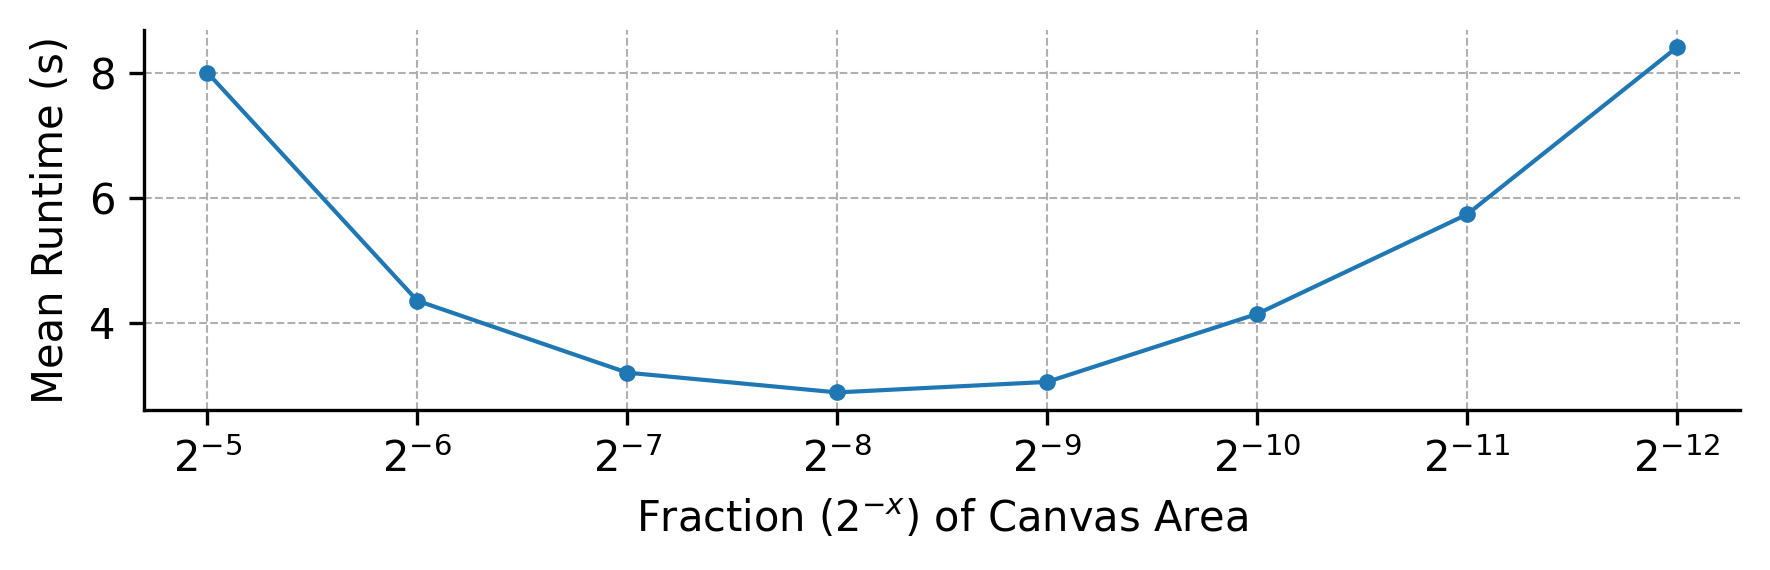

In [14]:
mean_over_maps = df.groupby('neg_expo')['mean'].mean().reset_index()

exponents = mean_over_maps['neg_expo'].astype(int)
frac_labels = [rf'$2^{{-{e}}}$' for e in exponents]


fig, ax = plt.subplots(figsize=(6, 2), dpi=300)
ax.plot(
    exponents,
    mean_over_maps['mean'],
    marker='o',
    linewidth=1,
    markersize=3,
)

ax.set_xticks(exponents)
ax.set_xticklabels(frac_labels)

ax.set_xlabel('Fraction (' + r'$2^{-x}$' + ') of Canvas Area')
ax.set_ylabel('Mean Runtime (s)')           # or 'Mean relative error' etc.

ax.set_xlim(exponents.min() - 0.3, exponents.max() + 0.3)

ax.grid(linestyle='--', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

fig.savefig('Quadtree_Depth.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [15]:
mean_over_maps

,neg_expo,mean
0,5,8.009598
1,6,4.354652
2,7,3.202612
3,8,2.886797
4,9,3.055015
5,10,4.144050
6,11,5.738390
7,12,8.415491


In [16]:
df_wide = df

df_wide = df_wide.rename(columns={'command': 'map_name'})

df_wide = df_wide.pivot(index='map_name', columns='neg_expo', values='mean').reset_index()

df_wide = df_wide.sort_values('map_name')
df_wide.columns.name = None

df_wide

,map_name,5,6,7,8,9,10,11,12
0,Algeria Population by Wilaya (2022),2.076166,1.484563,1.033027,0.946907,1.063175,1.280391,1.695442,5.509033
1,Australia Population by State and Territory (2...,1.674171,1.121241,0.813035,0.753836,0.705438,0.880091,1.137647,2.876533
2,Austria Population by State (2020),0.762217,0.432292,0.269640,0.244231,0.261824,0.265309,0.351603,0.710117
3,Bahamas Population by District (2010),4.639639,3.580797,3.321783,3.360702,3.819111,4.428403,5.277186,17.013014
4,Belgium Population by Region (2022),0.610753,0.286160,0.157068,0.097617,0.077192,0.063332,0.056375,0.094201
5,Brazil Population by State (2021),1.529486,0.922225,0.727777,0.637408,0.729530,0.784325,0.935732,1.413129
6,China Population by Province (2020),1.883710,1.308682,0.903790,0.782955,0.882367,1.048512,1.476073,2.122588
7,Conterminous USA Population by State (2020),0.976520,0.645138,0.488811,0.512594,0.632132,0.837551,1.320537,2.065375
8,Croatia Covid Cases by County (2022),0.725262,0.374611,0.287881,0.284086,0.337414,0.357408,0.598206,0.942511
9,Croatia Population by County (2021),0.683548,0.367792,0.231207,0.188726,0.247794,0.330001,0.416149,0.824906


In [17]:
neg_cols = [str(c) for c in df_wide.columns if c != 'map_name']
n = len(neg_cols)

pd.set_option('display.max_colwidth', None)


latex_table = df_wide.to_latex(
    index=False,
    escape=True,
    multirow=True,
    float_format="%.4f"
)

parts = latex_table.split('\\midrule', 1)
if len(parts) < 2:
    raise ValueError("Could not find '\\midrule' in the generated LaTeX code.")

custom_header = r"""\begin{tabular}{lrrrrrrrr}
\toprule
Map & \multicolumn{8}{c}{\shortstack{Runtime of Cartogram Generation\\ if Quadtree Target Number of Cells Chosen\\ as Area of Canvas \times $2^{-x}$}} \\
\cmidrule(lr){2-9}
     & 5 & 6 & 7 & 8 & 9 & 10 & 11 & 12 \\
\midrule
"""


final_latex = custom_header + parts[1]

with open("latex.tex", "w") as f:
    f.write(final_latex)

/var/folders/60/pcj600xj0lb0c65fpdgj2kgr0000gn/T/ipykernel_73325/1560205396.py:7: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_table = df_wide.to_latex(
